In [ ]:
import pandas as pd
import numpy as np

# Display options (optional, helps when exploring)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Load data
file_path = "synthetic_fraud_data.csv"  
df = pd.read_csv(file_path)

# Quick sanity checks
print("Shape (rows, columns):", df.shape)
print("\nColumns:", df.columns.tolist())



Shape (rows, columns): (7483766, 24)

Columns: ['transaction_id', 'customer_id', 'card_number', 'timestamp', 'merchant_category', 'merchant_type', 'merchant', 'amount', 'currency', 'country', 'city', 'city_size', 'card_type', 'card_present', 'device', 'channel', 'device_fingerprint', 'ip_address', 'distance_from_home', 'high_risk_merchant', 'transaction_hour', 'weekend_transaction', 'velocity_last_hour', 'is_fraud']


In [2]:
df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
7483761    False
7483762    False
7483763    False
7483764    False
7483765    False
Length: 7483766, dtype: bool

In [3]:
# Check dtypes and non-null counts
print("=== df.info() ===")
print(df.info())

# Peek at first few rows
print("\n=== df.head() ===")
print(df.head())

# Basic statistics for numeric columns
print("\n=== describe (numeric) ===")
print(df.describe().T)

# Target distribution
print("\n=== is_fraud value_counts ===")
print(df["is_fraud"].value_counts(dropna=False))
print("\n=== is_fraud value_counts(normalize=True) ===")
print(df["is_fraud"].value_counts(normalize=True, dropna=False))

# Check missing values per column
print("\n=== Missing values per column ===")
print(df.isna().sum().sort_values(ascending=False))


=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7483766 entries, 0 to 7483765
Data columns (total 24 columns):
 #   Column               Dtype  
---  ------               -----  
 0   transaction_id       object 
 1   customer_id          object 
 2   card_number          int64  
 3   timestamp            object 
 4   merchant_category    object 
 5   merchant_type        object 
 6   merchant             object 
 7   amount               float64
 8   currency             object 
 9   country              object 
 10  city                 object 
 11  city_size            object 
 12  card_type            object 
 13  card_present         bool   
 14  device               object 
 15  channel              object 
 16  device_fingerprint   object 
 17  ip_address           object 
 18  distance_from_home   int64  
 19  high_risk_merchant   bool   
 20  transaction_hour     int64  
 21  weekend_transaction  bool   
 22  velocity_last_hour   object 
 23  is_fraud      

In [4]:
# 1) Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

print(df['timestamp'].head())
print("\nAny NaT after conversion?:", df['timestamp'].isna().sum())

# 2) Basic target check again
print("\nFraud distribution:")
print(df['is_fraud'].value_counts(normalize=True))

# 3) Quick look at amount
print("\nAmount describe:")
print(df['amount'].describe())


0   2024-09-30 00:00:01.034820+00:00
1   2024-09-30 00:00:01.764464+00:00
2   2024-09-30 00:00:02.273762+00:00
3   2024-09-30 00:00:02.297466+00:00
4   2024-09-30 00:00:02.544063+00:00
Name: timestamp, dtype: datetime64[ns, UTC]

Any NaT after conversion?: 12

Fraud distribution:
is_fraud
False    0.800272
True     0.199728
Name: proportion, dtype: float64

Amount describe:
count    7.483766e+06
mean     4.792468e+04
std      1.775562e+05
min      1.000000e-02
25%      3.635300e+02
50%      1.177450e+03
75%      2.242953e+04
max      6.253153e+06
Name: amount, dtype: float64


Rows with NaT in timestamp: 12

Amount grouped by is_fraud:
              count           mean            std    min       25%       50%        75%         max
is_fraud                                                                                           
False     5989038.0   30242.563375   87656.879726  17.95  368.2200   903.510  14535.915  1240629.47
True      1494716.0  118773.826058  347543.241870   0.01  295.5875  5626.175  63557.055  6253152.62


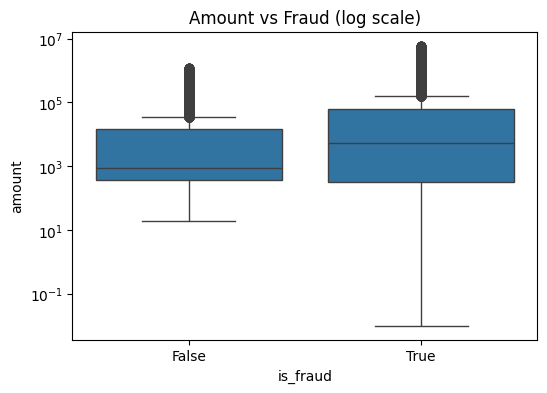

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Rows with NaT in timestamp:", df['timestamp'].isna().sum())
df = df[~df['timestamp'].isna()]  

print("\nAmount grouped by is_fraud:")
print(df.groupby('is_fraud')['amount'].describe())

plt.figure(figsize=(6,4))
sns.boxplot(data=df.sample(100000, random_state=42), x='is_fraud', y='amount')
plt.yscale('log')  
plt.title('Amount vs Fraud (log scale)')
plt.show()


Top 10 merchant_category by count and their fraud rates:
Healthcare                     | Count:  936768 | Fraud Rate: 19.938%
Restaurant                     | Count:  936176 | Fraud Rate: 19.970%
Entertainment                  | Count:  936170 | Fraud Rate: 19.963%
Retail                         | Count:  935882 | Fraud Rate: 19.940%
Travel                         | Count:  935790 | Fraud Rate: 20.034%
Gas                            | Count:  935400 | Fraud Rate: 19.973%
Grocery                        | Count:  934028 | Fraud Rate: 20.019%
Education                      | Count:  933540 | Fraud Rate: 19.946%


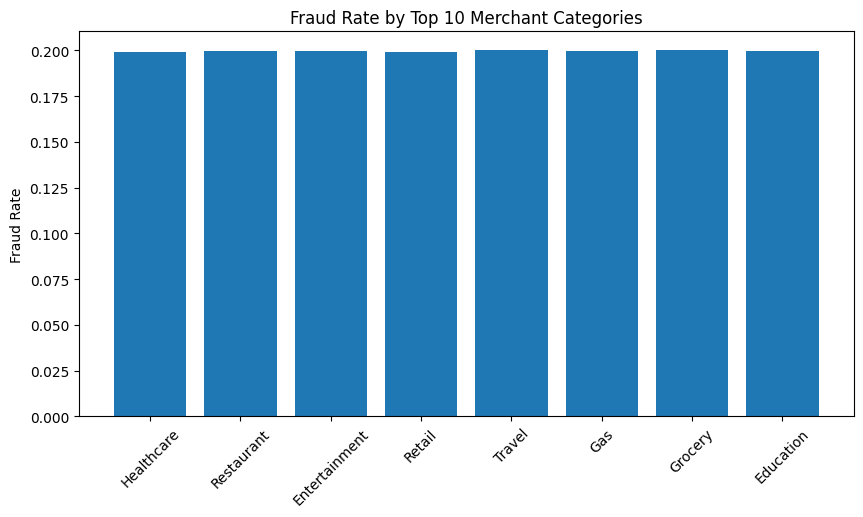

In [ ]:
# Fraud rate by merchant_category
cat_col = 'merchant_category'
cat_counts = df[cat_col].value_counts().head(10)  # Top 10 categories

# Aggregate fraud rate for these
print("Top 10 merchant_category by count and their fraud rates:")
for cat in cat_counts.index:
    n_total = df[df[cat_col] == cat].shape[0]
    n_fraud = df[(df[cat_col] == cat) & (df['is_fraud'])].shape[0]
    fraud_rate = n_fraud / n_total if n_total else 0
    print(f"{cat:30s} | Count: {n_total:7d} | Fraud Rate: {fraud_rate:.3%}")

#  barplot
import matplotlib.pyplot as plt

fraud_rates = [(cat, 
                df[(df[cat_col] == cat) & (df['is_fraud'])].shape[0] / df[df[cat_col] == cat].shape[0]) 
                for cat in cat_counts.index]

plt.figure(figsize=(10,5))
plt.bar([x[0] for x in fraud_rates], [x[1] for x in fraud_rates])
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Top 10 Merchant Categories')
plt.xticks(rotation=45)
plt.show()


In [7]:
def fraud_rate_by(col):
    print(f"\n=== {col} ===")
    tab = df.groupby(col)['is_fraud'].agg(['count', 'mean']).reset_index()
    tab = tab.sort_values('mean', ascending=False)
    tab.rename(columns={'mean': 'fraud_rate'}, inplace=True)
    print(tab)

for c in ['card_present', 'channel', 'high_risk_merchant']:
    fraud_rate_by(c)



=== card_present ===
   card_present    count  fraud_rate
1          True   651047    1.000000
0         False  6832707    0.123475

=== channel ===
  channel    count  fraud_rate
1     pos   651047    1.000000
0  mobile  2269572    0.123878
2     web  4563135    0.123275

=== high_risk_merchant ===
   high_risk_merchant    count  fraud_rate
1                True  1871960    0.199986
0               False  5611794    0.199642


In [8]:
# Hour of day vs fraud
print("=== Fraud rate by transaction_hour ===")
hour_tab = df.groupby('transaction_hour')['is_fraud'].agg(['count', 'mean']).reset_index()
hour_tab.rename(columns={'mean': 'fraud_rate'}, inplace=True)
print(hour_tab.sort_values('fraud_rate', ascending=False))

# Weekend vs weekday
print("\n=== Fraud rate by weekend_transaction ===")
weekend_tab = df.groupby('weekend_transaction')['is_fraud'].agg(['count', 'mean']).reset_index()
weekend_tab.rename(columns={'mean': 'fraud_rate'}, inplace=True)
print(weekend_tab)

# Velocity feature
print("\n=== velocity_last_hour describe by fraud ===")
print(df.groupby('is_fraud')['velocity_last_hour'].describe())


=== Fraud rate by transaction_hour ===
    transaction_hour   count  fraud_rate
1                  1  280136    0.592566
2                  2  280471    0.591947
3                  3  280031    0.591438
4                  4  281466    0.591254
0                  0  155759    0.266559
6                  6  196873    0.211415
21                21  196566    0.208831
5                  5  208529    0.200591
23                23  281728    0.147153
14                14  300151    0.138810
15                15  300554    0.138760
10                10  300516    0.137796
7                  7  301175    0.137186
20                20  300832    0.136914
22                22  332961    0.124432
11                11  352499    0.118744
13                13  352556    0.118645
9                  9  352451    0.117809
16                16  352379    0.117507
19                19  404820    0.103221
12                12  404942    0.103017
8                  8  405312    0.102447
17                

In [9]:
print(df['velocity_last_hour'].iloc[0])
print(type(df['velocity_last_hour'].iloc[0]))


{'num_transactions': 1197, 'total_amount': 33498556.080464985, 'unique_merchants': 105, 'unique_countries': 12, 'max_single_amount': 1925480.6324148502}
<class 'str'>


In [10]:
print(df['weekend_transaction'].dtype)
print(df['weekend_transaction'].value_counts(dropna=False).head())


bool
weekend_transaction
False    5554092
True     1929662
Name: count, dtype: int64


In [ ]:
print(df.columns.tolist())             

print([c for c in df.columns if 'vel' in c.lower()])


['transaction_id', 'customer_id', 'card_number', 'timestamp', 'merchant_category', 'merchant_type', 'merchant', 'amount', 'currency', 'country', 'city', 'city_size', 'card_type', 'card_present', 'device', 'channel', 'device_fingerprint', 'ip_address', 'distance_from_home', 'high_risk_merchant', 'transaction_hour', 'weekend_transaction', 'velocity_last_hour', 'is_fraud']
['velocity_last_hour']


In [ ]:
import pandas as pd
import numpy as np
import json
from ast import literal_eval

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])  

# 1) Parse the velocity_last_hour column
def parse_velocity(x):
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        x = x.strip()

        try:
            return json.loads(x)
        except Exception:
            try:
                return literal_eval(x)
            except Exception:
                return {}
    return {}

vel = df['velocity_last_hour'].map(parse_velocity)

# 2) Flatten to columns and prefix
vel_df = pd.json_normalize(vel).add_prefix('vel1h_')  # e.g., vel1h_num_transactions, vel1h_total_amount, ...
# Fill missing numeric with 0
for c in vel_df.columns:
    vel_df[c] = pd.to_numeric(vel_df[c], errors='coerce')
vel_df = vel_df.fillna(0)

# 3) Join back
df = pd.concat([df.drop(columns=['velocity_last_hour']), vel_df], axis=1)

# 4) Additional lightweight feature engineering
df['amount_log1p'] = np.log1p(df['amount'])
df['hour'] = df['transaction_hour'].astype('int16', errors='ignore')
df['is_night'] = df['hour'].isin([0,1,2,3,4,5]).astype('int8')
df['is_odd_hour'] = df['hour'].isin([1,2,3,4]).astype('int8')
df['is_weekend'] = (
    df['weekend_transaction']
    .fillna(False)
    .astype(bool)
    .astype('int8')
)

# 5) Drop/avoid known leaks and very ID-like columns
drop_cols = [
    'card_present',      # leak (in your data it perfectly matches fraud)
    'channel',           # POS looked like a leak
    'transaction_id','customer_id','card_number','device_fingerprint','ip_address',
    'timestamp'          # we’ll use it only for chronological split, not as a feature
]
drop_cols = [c for c in drop_cols if c in df.columns]
df_model = df.drop(columns=drop_cols)


KeyError: 'velocity_last_hour'

In [15]:
print(df.columns.tolist())              # full list

# Helpful filter
print([c for c in df.columns if 'vel' in c.lower()])


['transaction_id', 'customer_id', 'card_number', 'timestamp', 'merchant_category', 'merchant_type', 'merchant', 'amount', 'currency', 'country', 'city', 'city_size', 'card_type', 'card_present', 'device', 'channel', 'device_fingerprint', 'ip_address', 'distance_from_home', 'high_risk_merchant', 'transaction_hour', 'weekend_transaction', 'is_fraud', 'vel1h_num_transactions', 'vel1h_total_amount', 'vel1h_unique_merchants', 'vel1h_unique_countries', 'vel1h_max_single_amount', 'amount_log1p', 'hour', 'is_night', 'is_odd_hour']
['vel1h_num_transactions', 'vel1h_total_amount', 'vel1h_unique_merchants', 'vel1h_unique_countries', 'vel1h_max_single_amount']


In [ ]:
import numpy as np

df['is_weekend'] = (
    df['weekend_transaction']
    .fillna(False)
    .astype(bool)
    .astype('int8')
)

# Optionally convert high_risk_merchant to int as well
df['high_risk_merchant'] = (
    df['high_risk_merchant']
    .fillna(False)
    .astype(bool)
    .astype('int8')
)

# Columns to drop before modeling (IDs + leaks + raw weekend flag + timestamp)
drop_cols = [
    'transaction_id', 'customer_id', 'card_number',
    'device_fingerprint', 'ip_address',
    'card_present',          # leak
    'channel',               # POS looked like leak
    'timestamp',
    'weekend_transaction'    # replaced by is_weekend
]
drop_cols = [c for c in drop_cols if c in df.columns]

df_model = df.drop(columns=drop_cols)
print("df_model shape:", df_model.shape)
print("df_model columns:", df_model.columns.tolist())


C:\Users\moksh\AppData\Local\Temp\ipykernel_15684\437379627.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\moksh\AppData\Local\Temp\ipykernel_15684\437379627.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


df_model shape: (7483754, 24)
df_model columns: ['merchant_category', 'merchant_type', 'merchant', 'amount', 'currency', 'country', 'city', 'city_size', 'card_type', 'device', 'distance_from_home', 'high_risk_merchant', 'transaction_hour', 'is_fraud', 'vel1h_num_transactions', 'vel1h_total_amount', 'vel1h_unique_merchants', 'vel1h_unique_countries', 'vel1h_max_single_amount', 'amount_log1p', 'hour', 'is_night', 'is_odd_hour', 'is_weekend']


In [17]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ------------------------------------------------------------------
# 0) ASSUMPTION: df is already loaded and preprocessed to this point:
# - df has columns:
#   'transaction_id', 'customer_id', 'card_number', 'timestamp',
#   'merchant_category', 'merchant_type', 'merchant',
#   'amount', 'currency', 'country', 'city', 'city_size',
#   'card_type', 'card_present', 'device', 'channel',
#   'device_fingerprint', 'ip_address', 'distance_from_home',
#   'high_risk_merchant', 'transaction_hour', 'weekend_transaction',
#   'is_fraud',
#   'vel1h_num_transactions', 'vel1h_total_amount',
#   'vel1h_unique_merchants', 'vel1h_unique_countries',
#   'vel1h_max_single_amount', 'amount_log1p',
#   'hour', 'is_night', 'is_odd_hour'
# - df['timestamp'] is datetime
# ------------------------------------------------------------------

# 1) Make is_weekend and clean high_risk_merchant
df['is_weekend'] = (
    df['weekend_transaction']
    .fillna(False)
    .astype(bool)
    .astype('int8')
)

df['high_risk_merchant'] = (
    df['high_risk_merchant']
    .fillna(False)
    .astype(bool)
    .astype('int8')
)

# 2) Drop ID-like and leaky columns
drop_cols = [
    'transaction_id', 'customer_id', 'card_number',
    'device_fingerprint', 'ip_address',
    'card_present',          # leak
    'channel',               # POS looked like leak
    'timestamp',             # not used directly as feature
    'weekend_transaction'    # replaced by is_weekend
]
drop_cols = [c for c in drop_cols if c in df.columns]

df_model = df.drop(columns=drop_cols)
print("df_model shape:", df_model.shape)
print("df_model columns:", df_model.columns.tolist())

# 3) Set X, y
target = 'is_fraud'
y = df_model[target].astype(int)
X = df_model.drop(columns=[target])

# 4) Identify categorical and numeric columns
categorical_cols = [
    'merchant_category','merchant_type','merchant',
    'currency','country','city','city_size',
    'card_type','device'
]
categorical_cols = [c for c in categorical_cols if c in X.columns]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("\nTotal features:", X.shape[1])
print("Categorical features:", len(categorical_cols))
print("Numeric features:", len(numeric_cols))

# 5) Random 80/10/10 split with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("\nSplit sizes:")
print("Train size:", X_train.shape[0])
print("Valid size:", X_valid.shape[0])
print("Test size:",  X_test.shape[0])

# 6) CatBoost pools
cat_idx = [X.columns.get_loc(c) for c in categorical_cols]

train_pool = Pool(X_train, label=y_train, cat_features=cat_idx)
valid_pool = Pool(X_valid, label=y_valid, cat_features=cat_idx)
test_pool  = Pool(X_test,  label=y_test,  cat_features=cat_idx)

# 7) Class weights
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
class_weights = [1.0, neg / max(1, pos)]
print("\nClass weights:", class_weights)

# 8) Model definition and training
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.12,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=class_weights,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)

model.fit(train_pool, eval_set=valid_pool)

# 9) Validation metrics
valid_proba = model.predict_proba(valid_pool)[:, 1]
valid_pred  = (valid_proba >= 0.5).astype(int)

roc_valid = roc_auc_score(y_valid, valid_proba)
pr_valid  = average_precision_score(y_valid, valid_proba)
acc_valid = accuracy_score(y_valid, valid_pred)

print("\nVALIDATION METRICS:")
print(f"ROC-AUC:  {roc_valid:.4f}")
print(f"PR-AUC:   {pr_valid:.4f}")
print(f"Accuracy: {acc_valid:.4f}")

print("\nValidation confusion matrix @0.5:\n", confusion_matrix(y_valid, valid_pred))
print("\nValidation classification report @0.5:\n",
      classification_report(y_valid, valid_pred, digits=4))

# 10) Test metrics
test_proba = model.predict_proba(test_pool)[:, 1]
test_pred  = (test_proba >= 0.5).astype(int)

roc_test = roc_auc_score(y_test, test_proba)
pr_test  = average_precision_score(y_test, test_proba)
acc_test = accuracy_score(y_test, test_pred)

print("\nTEST METRICS:")
print(f"ROC-AUC:  {roc_test:.4f}")
print(f"PR-AUC:   {pr_test:.4f}")
print(f"Accuracy: {acc_test:.4f}")

print("\nTest confusion matrix @0.5:\n", confusion_matrix(y_test, test_pred))
print("\nTest classification report @0.5:\n",
      classification_report(y_test, test_pred, digits=4))

# 11) Feature importances
imp = pd.Series(model.get_feature_importance(valid_pool), index=X.columns).sort_values(ascending=False)
print("\nTop 25 feature importances:\n", imp.head(25))


C:\Users\moksh\AppData\Local\Temp\ipykernel_15684\2440157901.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


df_model shape: (7483754, 24)
df_model columns: ['merchant_category', 'merchant_type', 'merchant', 'amount', 'currency', 'country', 'city', 'city_size', 'card_type', 'device', 'distance_from_home', 'high_risk_merchant', 'transaction_hour', 'is_fraud', 'vel1h_num_transactions', 'vel1h_total_amount', 'vel1h_unique_merchants', 'vel1h_unique_countries', 'vel1h_max_single_amount', 'amount_log1p', 'hour', 'is_night', 'is_odd_hour', 'is_weekend']

Total features: 23
Categorical features: 9
Numeric features: 14

Split sizes:
Train size: 5987003
Valid size: 748375
Test size: 748376

Class weights: [1.0, np.float64(4.006805639531918)]
0:	test: 0.9773490	best: 0.9773490 (0)	total: 10.5s	remaining: 52m 17s
100:	test: 0.9948365	best: 0.9948365 (100)	total: 12m 8s	remaining: 23m 55s
200:	test: 0.9963716	best: 0.9963716 (200)	total: 19m 52s	remaining: 9m 53s
299:	test: 0.9969730	best: 0.9969730 (299)	total: 28m 52s	remaining: 0us

bestTest = 0.9969729818
bestIteration = 299


VALIDATION METRICS:
ROC-

C:\Users\moksh\AppData\Local\Temp\ipykernel_15684\891947568.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


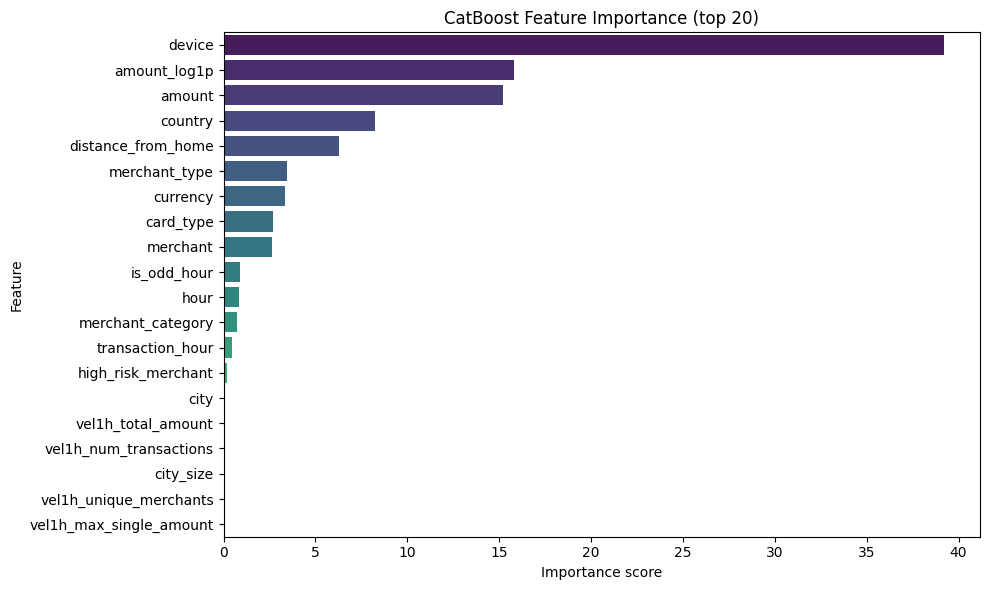

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fi_df = (
    imp.reset_index()
       .rename(columns={'index': 'feature', 0: 'importance'})
)

# Take top 20
fi_top = fi_df.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=fi_top,
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('CatBoost Feature Importance (top 20)')
plt.xlabel('Importance score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
import pickle

with open('catboost_fraud_model.pkl', 'wb') as f:
    pickle.dump(model, f)


In [ ]:
df.shape


(7483754, 24)

In [22]:
df_model.shape

(7483754, 24)

In [23]:
print("df columns:", df.columns.tolist())

drop_cols = [
    'transaction_id', 'customer_id', 'card_number',
    'device_fingerprint', 'ip_address',
    'card_present', 'channel',
    'timestamp', 'weekend_transaction'
]
drop_cols = [c for c in drop_cols if c in df.columns]

print("Drop columns that exist:", drop_cols)

df_model = df.drop(columns=drop_cols)
print("df_model shape:", df_model.shape)
print("df_model columns:", df_model.columns.tolist())


df columns: ['transaction_id', 'customer_id', 'card_number', 'timestamp', 'merchant_category', 'merchant_type', 'merchant', 'amount', 'currency', 'country', 'city', 'city_size', 'card_type', 'card_present', 'device', 'channel', 'device_fingerprint', 'ip_address', 'distance_from_home', 'high_risk_merchant', 'transaction_hour', 'weekend_transaction', 'is_fraud', 'vel1h_num_transactions', 'vel1h_total_amount', 'vel1h_unique_merchants', 'vel1h_unique_countries', 'vel1h_max_single_amount', 'amount_log1p', 'hour', 'is_night', 'is_odd_hour', 'is_weekend']
Drop columns that exist: ['transaction_id', 'customer_id', 'card_number', 'device_fingerprint', 'ip_address', 'card_present', 'channel', 'timestamp', 'weekend_transaction']
df_model shape: (7483754, 24)
df_model columns: ['merchant_category', 'merchant_type', 'merchant', 'amount', 'currency', 'country', 'city', 'city_size', 'card_type', 'device', 'distance_from_home', 'high_risk_merchant', 'transaction_hour', 'is_fraud', 'vel1h_num_transacti

In [ ]:
print("Target column in df_model:", 'is_fraud' in df_model.columns)
print("Features count:", df_model.shape[1] - 1)  


Target column in df_model: True
Features count: 23


In [25]:
print("df shape:", df.shape)
print("df_model shape:", df_model.shape)

print("\nColumns only in df (not in df_model):")
print(sorted(set(df.columns) - set(df_model.columns)))

print("\nColumns only in df_model (not in df):")
print(sorted(set(df_model.columns) - set(df.columns)))


df shape: (7483754, 33)
df_model shape: (7483754, 24)

Columns only in df (not in df_model):
['card_number', 'card_present', 'channel', 'customer_id', 'device_fingerprint', 'ip_address', 'timestamp', 'transaction_id', 'weekend_transaction']

Columns only in df_model (not in df):
[]


In [28]:
# After:
# X_train, X_temp, y_train, y_temp = ...
# X_valid, X_test, y_valid, y_test = ...

# 1) Reattach target to each split
train_df = X_train.copy()
train_df['is_fraud'] = y_train

valid_df = X_valid.copy()
valid_df['is_fraud'] = y_valid

test_df = X_test.copy()
test_df['is_fraud'] = y_test

print("Train df shape:", train_df.shape)
print("Valid df shape:", valid_df.shape)
print("Test df shape:",  test_df.shape)

# 2) Save each split independently
train_df.to_csv("train_split.csv", index=False)
valid_df.to_csv("valid_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)



Train df shape: (5987003, 24)
Valid df shape: (748375, 24)
Test df shape: (748376, 24)


In [29]:
import pandas as pd
import numpy as np
import pickle

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    accuracy_score
)

from catboost import Pool

# -------------------------------------------------
# 1) Load model and test data
# -------------------------------------------------
with open("catboost_fraud_model.pkl", "rb") as f:
    model = pickle.load(f)

test_df = pd.read_csv("test_split.csv")

print("Test df shape:", test_df.shape)
print("Test df columns:", test_df.columns.tolist())

# -------------------------------------------------
# 2) Separate features and target
# -------------------------------------------------
target = "is_fraud"
y_test = test_df[target].astype(int)
X_test = test_df.drop(columns=[target])

# -------------------------------------------------
# 3) Tell CatBoost which columns are categorical
#    (these must match what you used in training)
# -------------------------------------------------
categorical_cols = [
    "merchant_category", "merchant_type", "merchant",
    "currency", "country", "city", "city_size",
    "card_type", "device"
]
categorical_cols = [c for c in categorical_cols if c in X_test.columns]
cat_idx = [X_test.columns.get_loc(c) for c in categorical_cols]

test_pool = Pool(X_test, label=y_test, cat_features=cat_idx)

# -------------------------------------------------
# 4) Predict on test set
# -------------------------------------------------
test_proba = model.predict_proba(test_pool)[:, 1]
test_pred  = (test_proba >= 0.5).astype(int)

# -------------------------------------------------
# 5) Compute metrics
# -------------------------------------------------
roc_test = roc_auc_score(y_test, test_proba)
pr_test  = average_precision_score(y_test, test_proba)
acc_test = accuracy_score(y_test, test_pred)

print("\nTEST METRICS:")
print(f"ROC-AUC:  {roc_test:.4f}")
print(f"PR-AUC:   {pr_test:.4f}")
print(f"Accuracy: {acc_test:.4f}")

print("\nTest confusion matrix @0.5:\n", confusion_matrix(y_test, test_pred))
print("\nTest classification report @0.5:\n",
      classification_report(y_test, test_pred, digits=4))

# -------------------------------------------------
# 6) Optional: inspect a few sample predictions
# -------------------------------------------------
n_samples = 5
sample = X_test.sample(n=n_samples, random_state=42)
sample_idx = sample.index

sample_proba = model.predict_proba(sample)[:, 1]
sample_pred  = (sample_proba >= 0.5).astype(int)
true_labels  = y_test.loc[sample_idx].values

sample_result = sample.copy()
sample_result["true_is_fraud"] = true_labels
sample_result["pred_proba"]    = sample_proba
sample_result["pred_label"]    = sample_pred

print(f"\nSample predictions ({n_samples} rows):")
cols_to_show = [
    "amount", "distance_from_home",
    "vel1h_num_transactions", "vel1h_total_amount",
    "amount_log1p", "hour", "is_night",
    "true_is_fraud", "pred_proba", "pred_label"
]
cols_to_show = [c for c in cols_to_show if c in sample_result.columns]
print(sample_result[cols_to_show])


Test df shape: (748376, 24)
Test df columns: ['merchant_category', 'merchant_type', 'merchant', 'amount', 'currency', 'country', 'city', 'city_size', 'card_type', 'device', 'distance_from_home', 'high_risk_merchant', 'transaction_hour', 'vel1h_num_transactions', 'vel1h_total_amount', 'vel1h_unique_merchants', 'vel1h_unique_countries', 'vel1h_max_single_amount', 'amount_log1p', 'hour', 'is_night', 'is_odd_hour', 'is_weekend', 'is_fraud']

TEST METRICS:
ROC-AUC:  0.9970
PR-AUC:   0.9912
Accuracy: 0.9763

Test confusion matrix @0.5:
 [[585730  13174]
 [  4543 144929]]

Test classification report @0.5:
               precision    recall  f1-score   support

           0     0.9923    0.9780    0.9851    598904
           1     0.9167    0.9696    0.9424    149472

    accuracy                         0.9763    748376
   macro avg     0.9545    0.9738    0.9637    748376
weighted avg     0.9772    0.9763    0.9766    748376


Sample predictions (5 rows):
           amount  distance_from_hom